# TP 8 - LSTM pour prévision prix du Bitcoin

L'objectif de ce notebook est de construire un réseau de neurones de type LSTM pour prévoir les cours du Bitcoin du lendemain.

## Import des librairies

In [67]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Cache les warnings CUDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import math
from keras.models import Sequential
from keras.layers import Input, Dense, SimpleRNN, LSTM, Dropout
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error


## Analyse univariée

### Chargement des données

In [2]:
df = pd.read_csv("./data/BTCUSDT_daily.csv", index_col=0, parse_dates=True)

In [3]:
# Aperçu des données
df

,Open,High,Low,Close,Volume,QuoteAssetVolume,AverageTradedPrice
Timestamp,,,,,,,
2022-01-01,46216.93,47954.63,46208.37,47722.65,19604.46325,9.241552e+08,47140.038868
2022-01-02,47722.66,47990.00,46654.00,47286.18,18340.46040,8.666110e+08,47251.321759
2022-01-03,47286.18,47570.00,45696.00,46446.10,27662.07710,1.292204e+09,46713.900177
2022-01-04,46446.10,47557.54,45500.00,45832.01,35491.41360,1.649170e+09,46466.743836
2022-01-05,45832.01,47070.00,42500.00,43451.13,51784.11857,2.334289e+09,45077.305728
...,...,...,...,...,...,...,...
2026-02-09,70330.38,71453.53,68308.00,70138.00,29152.72842,2.038960e+09,69940.607618
2026-02-10,70138.00,70527.59,67800.00,68841.29,20373.77072,1.408624e+09,69139.073111
2026-02-11,68841.28,69292.88,65756.00,67082.52,28718.24602,1.930514e+09,67222.557610


In [4]:
# Analyse des données (type, valeurs nulles)
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1505 entries, 2022-01-01 to 2026-02-13
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Open                1505 non-null   float64
 1   High                1505 non-null   float64
 2   Low                 1505 non-null   float64
 3   Close               1505 non-null   float64
 4   Volume              1505 non-null   float64
 5   QuoteAssetVolume    1505 non-null   float64
 6   AverageTradedPrice  1505 non-null   float64
dtypes: float64(7)
memory usage: 94.1 KB


In [5]:
# Extraction des cours de clôture
X = df['Close']

In [6]:
X.info()

<class 'pandas.Series'>
DatetimeIndex: 1505 entries, 2022-01-01 to 2026-02-13
Series name: Close
Non-Null Count  Dtype  
--------------  -----  
1505 non-null   float64
dtypes: float64(1)
memory usage: 23.5 KB


In [7]:
# Conversion des données en format compatible keras
X = X.values
X = X.astype('float32')
X = X.reshape(-1, 1)  # conversion en array avec 1 colonne

In [8]:
X

array([[47722.65],
       [47286.18],
       [46446.1 ],
       ...,
       [67082.52],
       [66272.17],
       [68976.  ]], shape=(1505, 1), dtype=float32)

In [9]:
# Normalisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

(array([-200.,    0.,  200.,  400.,  600.,  800., 1000., 1200., 1400.,
        1600.]),
 [Text(-200.0, 0, '−200'),
  Text(0.0, 0, '0'),
  Text(200.0, 0, '200'),
  Text(400.0, 0, '400'),
  Text(600.0, 0, '600'),
  Text(800.0, 0, '800'),
  Text(1000.0, 0, '1000'),
  Text(1200.0, 0, '1200'),
  Text(1400.0, 0, '1400'),
  Text(1600.0, 0, '1600')])

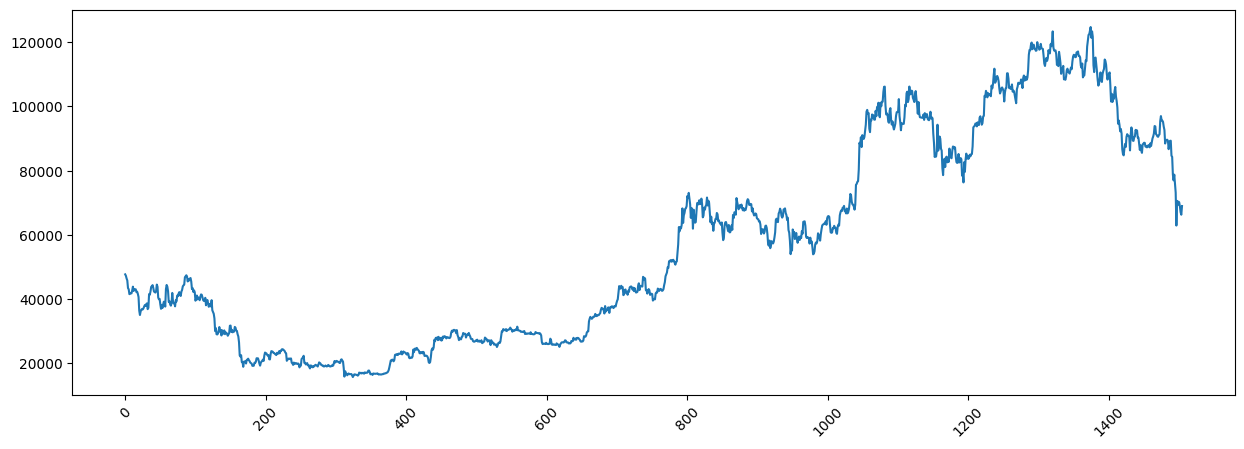

In [10]:
# Graphique des prix du Bitcoin
plt.figure(figsize = (15, 5))
plt.plot(X)
plt.xticks(rotation = 45)

## Création d'un train set et d'un test set

In [11]:
train_size = int(len(X_scaled) * 0.80)
test_size = len(X_scaled) - train_size
# Train/test split for time series
train, test = X_scaled[0:train_size,:], X_scaled[train_size:len(X_scaled),:]

## Préparation des données pour Keras

In [58]:
# Nombre de données passées utilisées pour la prédiction
seq_size = length = 10
# Nombre d'échantillons envoyés au modèle en une seule itération
# Sert à l'entrainement des poids
batch_size = 1
train_generator = TimeseriesGenerator(data = train,  # input data
                                      targets = train,  # modèle univarié
                                      length = length,  #lookback, profondeur de la mémoire
                                      stride = 1, # pas de 1 = prévision jour suivant
                                      batch_size = batch_size)
print("Nombre de valeurs dans le train set =", len(train))
print("Nombre de valeurs dans train_generator =", len(train_generator))

Nombre de valeurs dans le train set = 1204
Nombre de valeurs dans train_generator = 1194


Plus batch_size est petit, plus il y a de risque d'overfitting. Accroitre la taille du batch permet de gébéraliser le modèle lors de l'aprentissage.

In [59]:
x, y = train_generator[0]
print(x)
print(y)

[[[-0.28756502]
  [-0.30109552]
  [-0.32713786]
  [-0.3461746 ]
  [-0.41998175]
  [-0.43141514]
  [-0.47840568]
  [-0.4748947 ]
  [-0.46916336]
  [-0.47046947]]]
[[-0.44235873]]


In [60]:
x, y = train_generator[1]
print(x)
print(y)

[[[-0.30109552]
  [-0.32713786]
  [-0.3461746 ]
  [-0.41998175]
  [-0.43141514]
  [-0.47840568]
  [-0.4748947 ]
  [-0.46916336]
  [-0.47046947]
  [-0.44235873]]]
[[-0.4059843]]


Choix d'un batch_size de 16

In [62]:
# Nombre de données passées utilisées pour la prédiction
seq_size = length = 10
# Nombre d'échantillons envoyés au modèle en une seule itération
# Sert à l'entrainement des poids
batch_size = 16
train_generator = TimeseriesGenerator(data = train,  # input data
                                      targets = train,  # modèle univarié
                                      length = length,  #lookback, profondeur de la mémoire
                                      stride = 1, # pas de 1 = prévision jour suivant
                                      batch_size = batch_size)
print("Nombre de valeurs dans le train set =", len(train))
print("Nombre de batches dans train_generator =", len(train_generator))

Nombre de valeurs dans le train set = 1204
Nombre de batches dans train_generator = 75


In [64]:
# Génération des données utilisées pour la validation
val_generator = TimeseriesGenerator(test, test, length=length, batch_size=batch_size)
print("Nombre de valeurs dans le validation set =", len(test))
print("Nombre de batches dans le test set =", len(val_generator))

Nombre de valeurs dans le validation set = 301
Nombre de batches dans le test set = 19


In [40]:
# univarié = 1 feature
nb_feature = 1

## Construction du modèle LSTM

Modèle avec 2 couches LSTM contenant 50 neurones chacunes

In [97]:
model = Sequential([
Input(shape=(length, nb_feature)),
LSTM(50, activation='relu', return_sequences=True),
LSTM(50, activation='relu'),
Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error', )

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 10, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

## Entraînement et prédiction

In [98]:
# Entrainement du modèle
history = model.fit(train_generator, verbose=2,
                    epochs=10, validation_data=val_generator)


Epoch 1/10
75/75 - 2s - 26ms/step - loss: 0.3101 - val_loss: 0.2998
Epoch 2/10
75/75 - 0s - 4ms/step - loss: 0.0189 - val_loss: 0.2364
Epoch 3/10
75/75 - 0s - 4ms/step - loss: 0.0142 - val_loss: 0.0315
Epoch 4/10
75/75 - 0s - 4ms/step - loss: 0.0095 - val_loss: 0.0378
Epoch 5/10
75/75 - 0s - 4ms/step - loss: 0.0116 - val_loss: 0.0282
Epoch 6/10
75/75 - 0s - 4ms/step - loss: 0.0080 - val_loss: 0.0261
Epoch 7/10
75/75 - 0s - 4ms/step - loss: 0.0106 - val_loss: 0.0289
Epoch 8/10
75/75 - 0s - 4ms/step - loss: 0.0080 - val_loss: 0.0193
Epoch 9/10
75/75 - 0s - 4ms/step - loss: 0.0079 - val_loss: 0.0383
Epoch 10/10
75/75 - 0s - 4ms/step - loss: 0.0074 - val_loss: 0.0316
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [ ]:
# prédiction sur le train set et le test set
train_pred = model.predict(train_generator)
test_pred = model.predict(val_generator)

In [99]:
test_pred.shape

(291, 1)

A ce stade, les prédictions sont effectuées sur une échelle normalisée. Il convient de rétablir l'échelle de prix d'origine.

In [100]:
# Remise à l'échelle des variables
train_pred = scaler.inverse_transform(train_pred)
y_train_rescaled = scaler.inverse_transform(train)
test_pred = scaler. inverse_transform(test_pred)
y_test_rescaled = scaler.inverse_transform(test)

In [101]:
print(len(train))
print(len(train_pred))

1204
1194


In [102]:
train_pred

array([[44092.54 ],
       [43579.574],
       [43456.766],
       ...,
       [82636.086],
       [83124.92 ],
       [83631.25 ]], shape=(1194, 1), dtype=float32)

## Calcul de l'erreur de prévision

In [111]:
# calcul RMSE
train_score = math.sqrt(mean_squared_error(y_train_rescaled[length:], train_pred))
print(f"Score train set: {train_score} RMSE")
test_score = math.sqrt(mean_squared_error(y_test_rescaled[length:], test_pred))
print(f"Score test set: {test_score} RMSE")

Score train set: 2541.2489055580527 RMSE
Score test set: 5738.79098765585 RMSE


On voit que l'erreur est beaucoup plus élevée sur le test set, ce qui signale de l'overfitting.

In [104]:
print(len(train_pred))
print(len(test_pred))
print(len(X))

1194
291
1505


In [106]:
# Alignement des prédictions avec le dataset d'entraînement
train_pred_plot = np.empty_like(X)
train_pred_plot[:, :] = np.nan
train_pred_plot[length:len(train_pred)+(length), :] = train_pred

In [107]:
# Alignement des prédictions avec le dataset d'entraînement
test_pred_plot = np.empty_like(X)
test_pred_plot[:, :] = np.nan
test_pred_plot[len(train)+(length)-1:len(X) -1, :] = test_pred

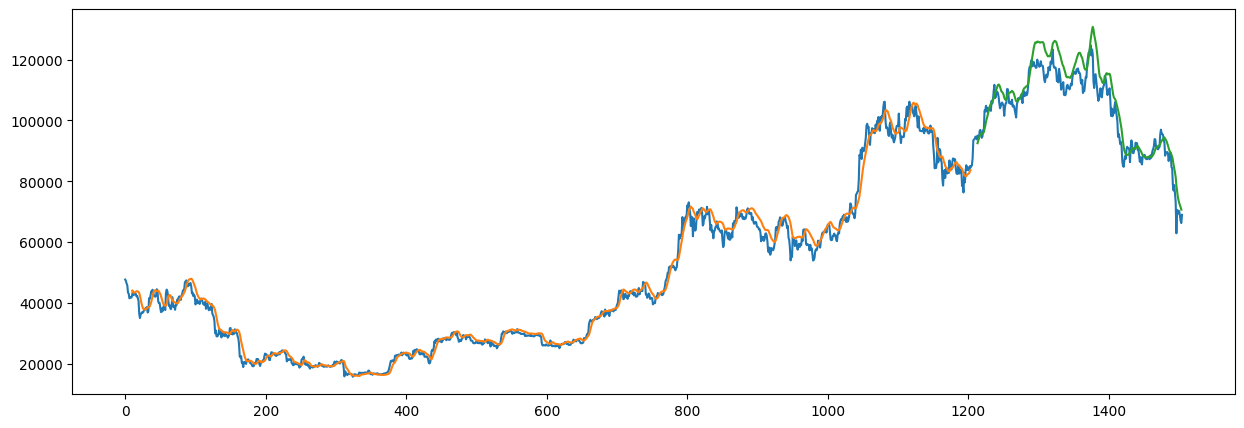

In [108]:
plt.figure(figsize = (15, 5))
plt.plot(scaler.inverse_transform(X_scaled))
plt.plot(train_pred_plot)
plt.plot(test_pred_plot)
plt.show()

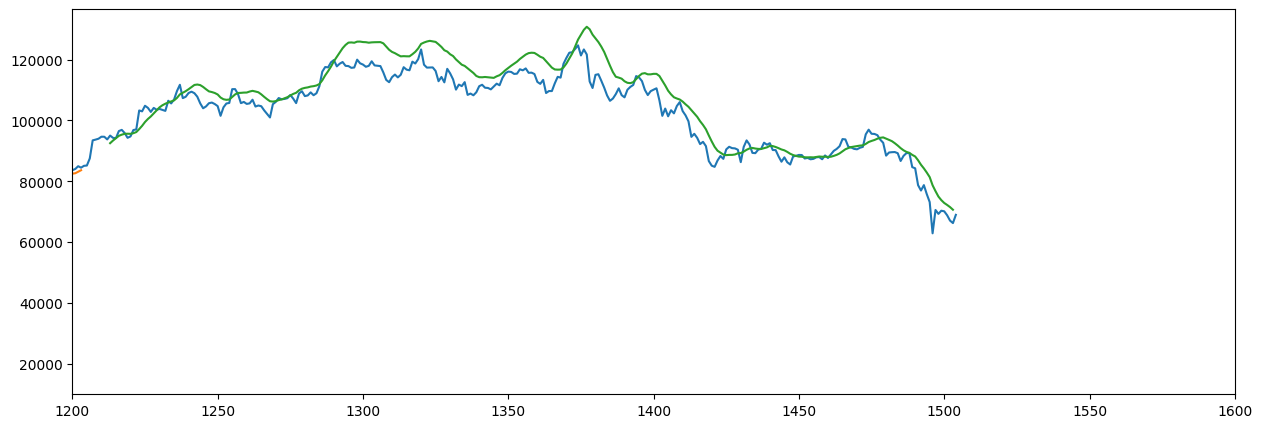

In [112]:
# Graphe prévisions sur test set
plt.figure(figsize = (15, 5))
plt.plot(scaler.inverse_transform(X_scaled))
plt.plot(train_pred_plot)
plt.plot(test_pred_plot)
plt.xlim(1200, 1600)
plt.show()